In [ ]:
"""
Project: Hierarchical CNN for Breast Cancer Histopathology (BreaKHis)
Author: Salah Eddine Kourradi (SEK171)
Date: April 2026
Description: Collective Hierarchical Classifier (Router -> [Experts] -> output)
""";

In [1]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 43.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=e8d174fe7b647009de29100ec1fa8c4166a5466c8724509c131205cdb90faffe
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import cv2
from PIL import Image
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [3]:
class CNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        
        # the conv blocks for feature extraction
        self.features = nn.Sequential(
            
            # first block: 3 channels for RGB (out = (W - K + 2P)/S + 1)
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # slide down the isle babyyy (224 -> 112)
            
            # second block: 32 -> 64 channels (112 -> 56)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # block 3: 64 -> 128 cs (56 -> 28)
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # block 4: 128 -> 256 cs (28 -> 14)
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # block 4: 256 -> 512 cs (14 -> 7)
            # 512 is plenty m8, and it's nice we can't divide 7 by 2 no more
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
            
        )
        
        # squishing time (7x7 -> 1x1) -> tensor shape will be (batch_size, 512, 1, 1)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # classifier blocks
        self.classifier = nn.Sequential(
            
            # linear layer with 512 * 1 so... 512... welp
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5), # dropping 50% just like my will to live
            
            nn.Linear(256, 128), # yknow the drill
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # we want the pure logits for crossentropy later
            nn.Linear(128, num_classes)
            
        )
        
        
    def forward(self, x):
        # extract the features
        x = self.features(x)
        
        # pool the space into 1d
        x = self.avg_pool(x)
        
        # flatten the tensor to become a (batch_size, 512) instead of a (batch_size, 512, 1, 1)
        x = torch.flatten(x, 1)
        
        # and finally classify
        x = self.classifier(x)
        
        return x


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
ROUTER_PATH = "/kaggle/input/notebooks/kourradisalaheddine/routermodel/router_model.pth"
EXPERT_40X_PATH = "/kaggle/input/notebooks/kourradisalaheddine/40xexpertmodel/expert_40x_model.pth"
EXPERT_100X_PATH = "/kaggle/input/notebooks/kourradisalaheddine/100xexpertmodel/expert_100x_model.pth"
EXPERT_200X_PATH = "/kaggle/input/notebooks/kourradisalaheddine/200xexpertmodel/expert_200x_model.pth"
EXPERT_400X_PATH = "/kaggle/input/notebooks/kourradisalaheddine/400xexpertmodel/expert_400x_model.pth"

In [6]:
# Router needs 4 outputs
router_model = CNN(num_classes=4).to(device)
router_model.load_state_dict(torch.load(ROUTER_PATH, map_location=device))
router_model.eval()

# expert models default to 2
expert_40x = CNN().to(device)
expert_40x.load_state_dict(torch.load(EXPERT_40X_PATH, map_location=device))
expert_40x.eval()

expert_100x = CNN().to(device)
expert_100x.load_state_dict(torch.load(EXPERT_100X_PATH, map_location=device))
expert_100x.eval()

expert_200x = CNN().to(device)
expert_200x.load_state_dict(torch.load(EXPERT_200X_PATH, map_location=device))
expert_200x.eval()

expert_400x = CNN().to(device)
expert_400x.load_state_dict(torch.load(EXPERT_400X_PATH, map_location=device))
expert_400x.eval()

experts = [expert_40x, expert_100x, expert_200x, expert_400x]

In [7]:
mean = [0.7867, 0.6264, 0.7641]
std = [0.1299, 0.1801, 0.1150]

In [8]:
inference_transforms = transforms.Compose([
    transforms.Resize((460, 700)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [9]:
def pipeline_predict_and_visualize(image_path, true_dataset="Unknown", true_diagnosis="Unknown"):
    raw_img_cv2 = cv2.imread(image_path)
    raw_img_rgb = cv2.cvtColor(raw_img_cv2, cv2.COLOR_BGR2RGB)
    raw_img_rgb = cv2.resize(raw_img_rgb, (700, 460)) # OpenCV Width x Height
    pil_image = Image.fromarray(raw_img_rgb)
    rgb_img_float = np.float32(raw_img_rgb) / 255
    tensor_image = inference_transforms(pil_image).to(device).unsqueeze(0)
    
    with torch.no_grad():
        # router
        router_out = router_model(tensor_image)
        _, router_idx = torch.max(router_out, 1)
        router_probs = F.softmax(router_out, dim=1)[0]
        
        mag_classes = ["40X", "100X", "200X", "400X"]
        predicted_magnification = mag_classes[router_idx.item()]
        router_conf = router_probs[router_idx.item()] * 100
        
        # expert
        active_model = experts[router_idx.item()]
        diagnosis_classes = ["Benign", "Malignant"]
        
        expert_out = active_model(tensor_image)
        _, expert_idx = torch.max(expert_out, 1)
        expert_probs = F.softmax(expert_out, dim=1)[0]
        
        predicted_diagnosis = diagnosis_classes[expert_idx.item()]
        expert_conf = expert_probs[expert_idx.item()] * 100

    print(f"File: {image_path}")
    print(f"ROUTER:  {predicted_magnification} ({router_conf:.1f}% conf) | True: {true_dataset}")
    print(f"EXPERT:  {predicted_diagnosis} ({expert_conf:.1f}% conf) | True: {true_diagnosis}")
    print("-" * 60)

    # gradcam on the active expert model
    target_layers = [active_model.features[-4]]
    cam = GradCAM(model=active_model, target_layers=target_layers)
    targets = [ClassifierOutputTarget(expert_idx.item())]
    
    grayscale_cam = cam(input_tensor=tensor_image, targets=targets)[0, :]
    visualization = show_cam_on_image(rgb_img_float, grayscale_cam, use_rgb=True)
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(raw_img_rgb)
    plt.title(f"Original\nZoom: {true_dataset} | Diag: {true_diagnosis}")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title(f"{predicted_magnification} Expert Focus\nPred: {predicted_diagnosis} ({expert_conf:.1f}%)")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

In [10]:
def evaluate_command_center(csv_path):
    df = pd.read_csv(csv_path)
    
    # create the matricies
    cm_router = torch.zeros(4, 4, dtype=torch.int32)
    cm_experts = [torch.zeros(2, 2, dtype=torch.int32) for _ in range(4)]
    cm_global = torch.zeros(8, 8, dtype=torch.int32)
    
    # Maps Mag_Idx (0-3) and Diag_Idx (0-1) to Global_Idx (0-7)
    # 40X(B)=0, 40X(M)=1, 100X(B)=2, 100X(M)=3, etc.
    def get_absolute_class(mag_idx, diag_idx):
        return (mag_idx * 2) + diag_idx
            
    print("Running Global Evaluation...")
    
    mag_map = {"40X": 0, "100X": 1, "200X": 2, "400X": 3}
    diag_map = {"Benign": 0, "Malignant": 1}
    
    for idx, row in df.iterrows():
        # READ DIRECTLY FROM CSV
        img_path = row['file_path']
        
        true_mag = row['magnification']
        true_diag = row['tumor_class']
        
        raw_img_cv2 = cv2.imread(img_path)
        if raw_img_cv2 is None: continue
        raw_img_rgb = cv2.cvtColor(raw_img_cv2, cv2.COLOR_BGR2RGB)
        raw_img_rgb = cv2.resize(raw_img_rgb, (700, 460))
        pil_image = Image.fromarray(raw_img_rgb)
        tensor_image = inference_transforms(pil_image).to(device).unsqueeze(0)
        
        source_idx = mag_map[true_mag]
        diag_idx = diag_map[true_diag]
        abs_idx = get_absolute_class(source_idx, diag_idx)
        
        with torch.no_grad():
            # route
            out_router = router_model(tensor_image)
            _, pred_router = torch.max(out_router, 1)
            routed_to = pred_router.item()
            
            # diagnose
            out_expert = experts[routed_to](tensor_image)
            _, pred_expert = torch.max(out_expert, 1)
            expert_diagnosis = pred_expert.item()
            
            # update matricies
            cm_router[source_idx, routed_to] += 1
            cm_experts[source_idx][diag_idx, expert_diagnosis] += 1
                
            # final outcome
            pred_abs = get_absolute_class(routed_to, expert_diagnosis)
            cm_global[abs_idx, pred_abs] += 1
            
        if (idx + 1) % 1000 == 0:
            print(f"Processed {idx + 1} / {len(df)} images...")

    def calc_acc(cm):
        return (torch.diag(cm).sum().float() / cm.sum()).item() * 100

    # plotting (6 graphs)
    fig, axes = plt.subplots(2, 3, figsize=(22, 14))
    axes = axes.flatten() # Flattens the 2x3 grid into a 1D array for easy looping
    sns.set_context("notebook", font_scale=1.1)

    # Plot 1: Router (Top Left)
    mag_names = ["40X", "100X", "200X", "400X"]
    sns.heatmap(cm_router.numpy(), annot=True, fmt='d', cmap='Greys', cbar=False, ax=axes[0],
                xticklabels=mag_names, yticklabels=mag_names)
    axes[0].set_title(f"Router Model\nAccuracy: {calc_acc(cm_router):.2f}%", pad=15, fontweight='bold')
    
    # Plots 2-5: The Four Experts
    diag_names = ["Benign", "Malignant"]
    cmap_colors = ['Blues', 'Oranges', 'Greens', 'Reds'] # Different color for each expert
    
    for i in range(4):
        ax = axes[i+1]
        cm_expert_safe = cm_experts[i].numpy()

        acc = calc_acc(cm_experts[i]) if cm_expert_safe.sum() > 0 else 0.0
        
        sns.heatmap(cm_expert_safe, annot=True, fmt='d', cmap=cmap_colors[i], cbar=False, ax=ax,
                    xticklabels=diag_names, yticklabels=diag_names)
        ax.set_title(f"{mag_names[i]} Expert\nAccuracy: {acc:.2f}%", pad=15, fontweight='bold')

    # Plot 6: Global Pipeline (Bottom Right)
    names_global = ["40(B)", "40(M)", "100(B)", "100(M)", "200(B)", "200(M)", "400(B)", "400(M)"]
    sns.heatmap(cm_global.numpy(), annot=True, fmt='d', cmap='Purples', cbar=False, ax=axes[5],
                xticklabels=names_global, yticklabels=names_global)
    axes[5].set_title(f"Unified Global Pipeline\nAccuracy: {calc_acc(cm_global):.2f}%", pad=15, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

File: /kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/phyllodes_tumor/SOB_B_PT_14-21998AB/400X/SOB_B_PT-14-21998AB-400-013.png
ROUTER:  400X (99.9% conf) | True: 400X
EXPERT:  Benign (86.1% conf) | True: Benign
------------------------------------------------------------


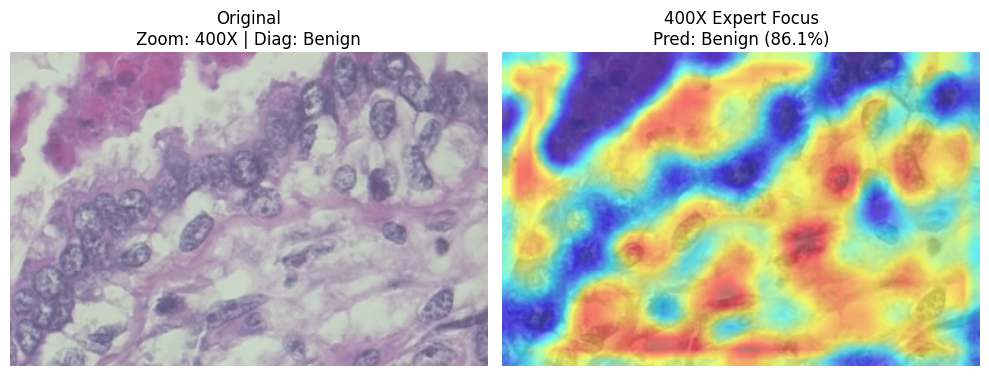

In [11]:
import random

# validation dataset
val_df = pd.read_csv("/kaggle/input/notebooks/kourradisalaheddine/routermodel/router_val.csv")

# pick a random image
sample_row = val_df.sample(n=1).iloc[0]

# get the path and original labels
image_path = sample_row['file_path']
true_mag = sample_row['magnification']
true_diag = sample_row['tumor_class']


# visualize
pipeline_predict_and_visualize(
    image_path=image_path, 
    true_dataset=true_mag, 
    true_diagnosis=true_diag
)

Running Global Evaluation...
Processed 1000 / 7909 images...
Processed 2000 / 7909 images...
Processed 3000 / 7909 images...
Processed 4000 / 7909 images...
Processed 5000 / 7909 images...
Processed 6000 / 7909 images...
Processed 7000 / 7909 images...


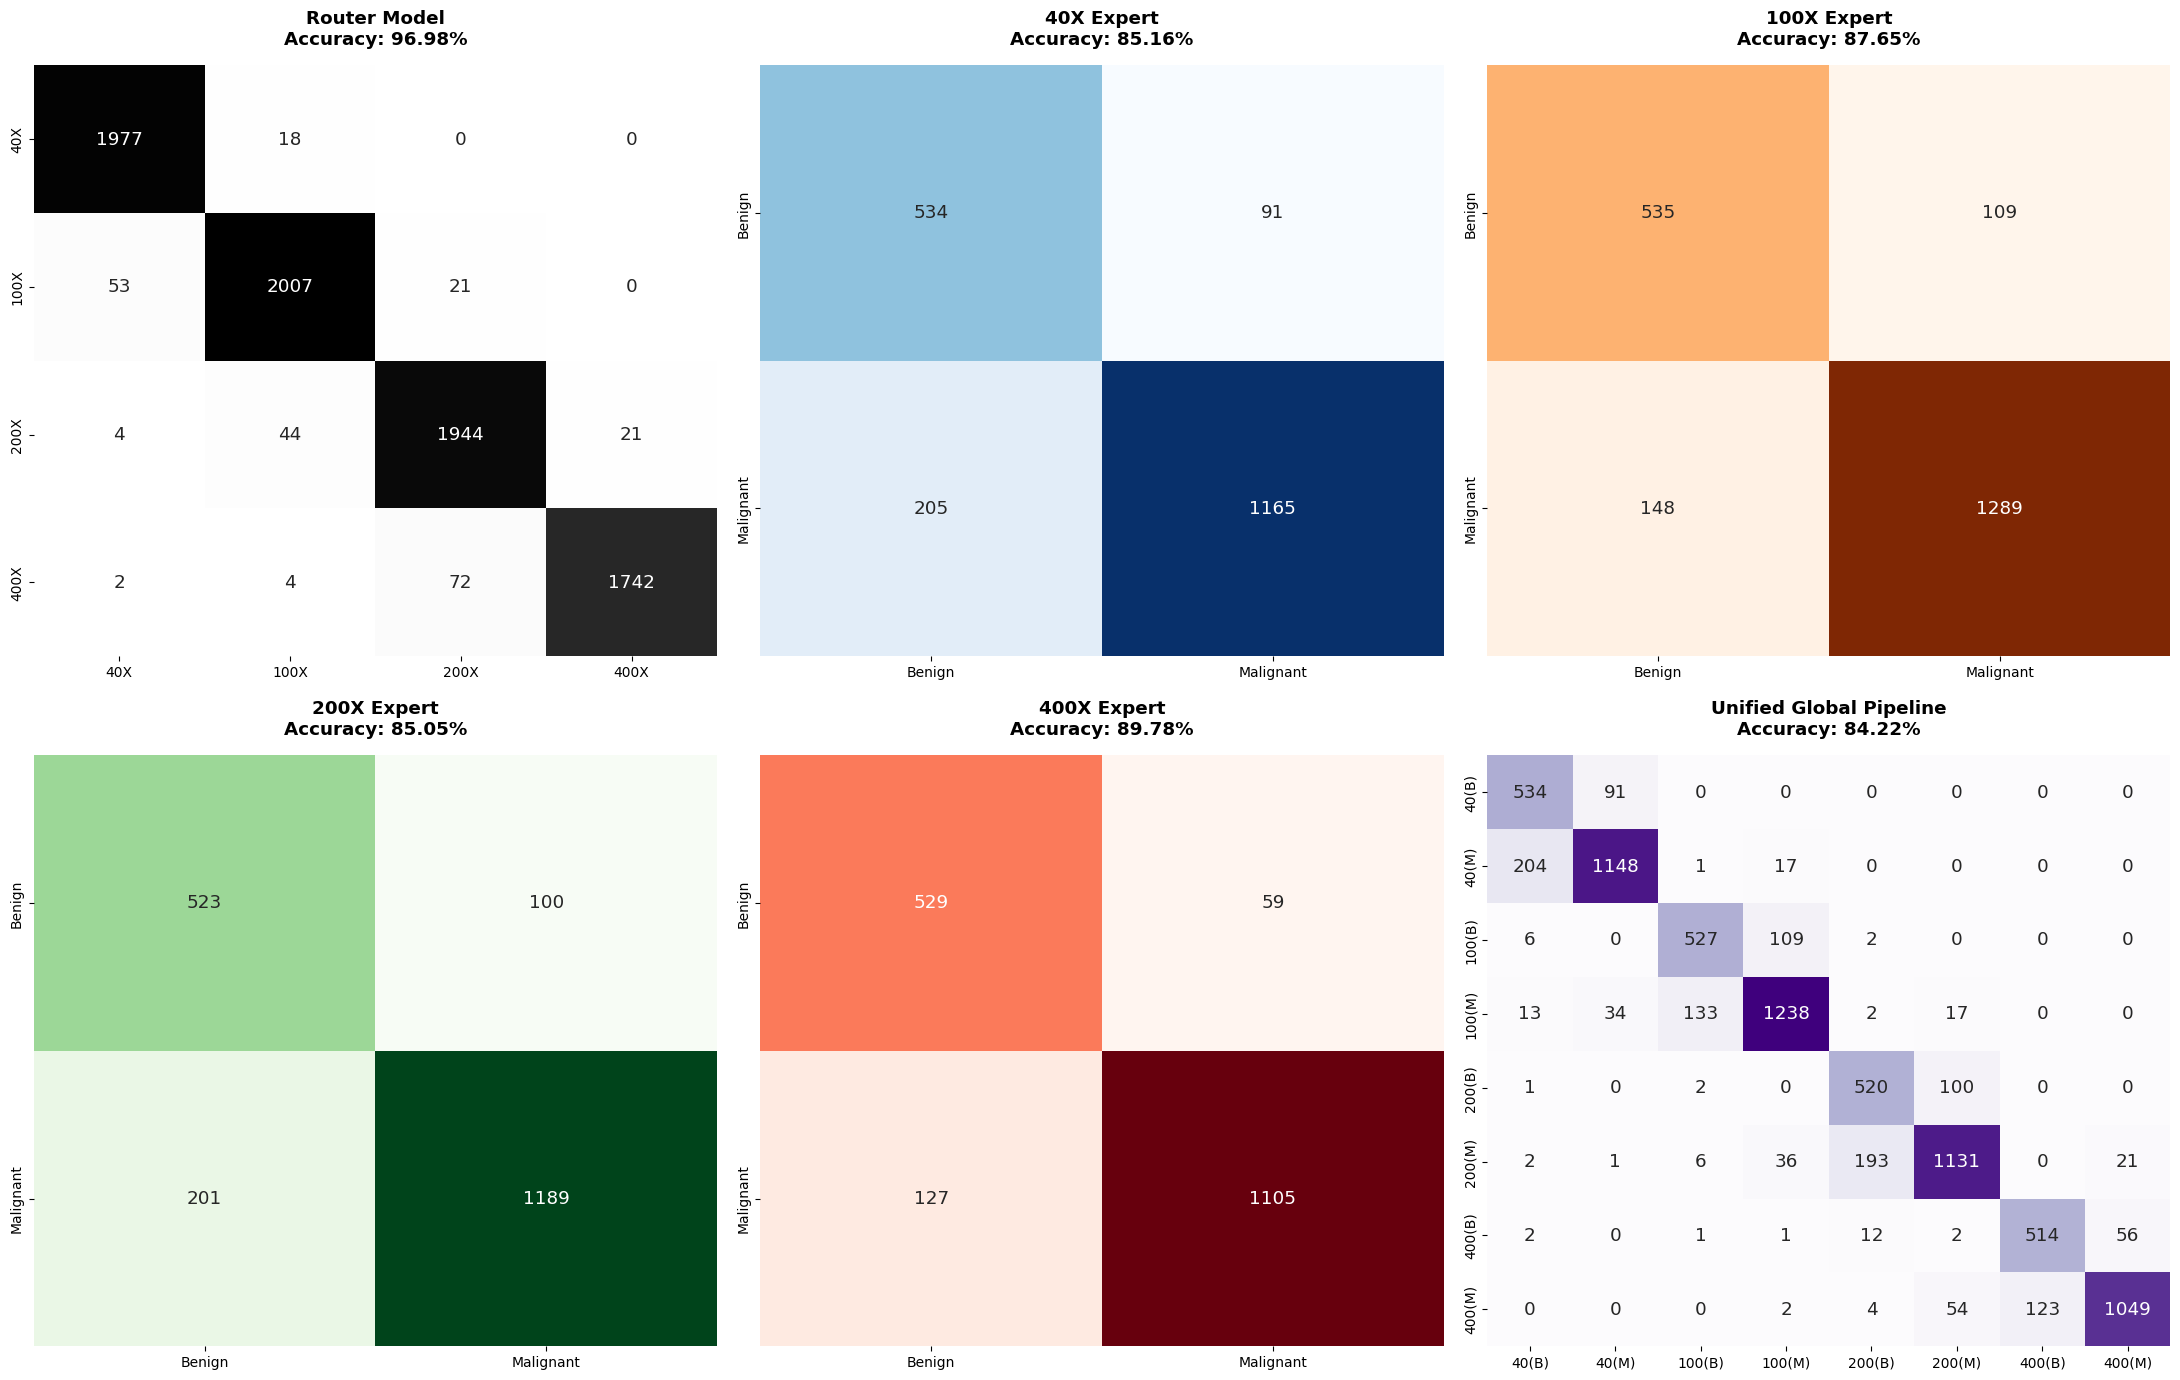

In [12]:
evaluate_command_center("/kaggle/input/notebooks/kourradisalaheddine/master-data-csv/master_dataset.csv")